<a href="https://colab.research.google.com/github/alimohmedelsaid26-cell/1000MLEngineer/blob/main/Comparative_Analysis_of_LSTM_Data_Framing_Window_vs_Time_Steps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Starting Experiment: WINDOW Method ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Test Score (window): 65.39 RMSE

--- Starting Experiment: TIME_STEPS Method ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Test Score (time_steps): 49.58 RMSE

FINAL COMPARISON RESULTS
Method: window       | Test RMSE: 65.39
Method: time_steps   | Test RMSE: 49.58


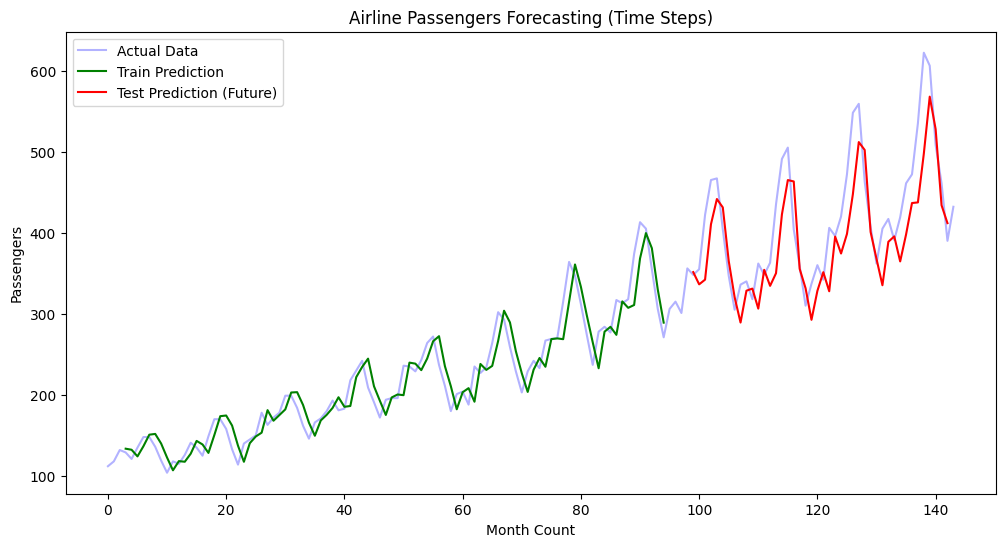

In [3]:
import numpy
import matplotlib.pyplot as plt
import math
from pandas import read_csv
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# --- 1. Dataset Preparation Function ---
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        dataX.append(a)
        dataY.append(dataset[i + look_back, 0])
    return numpy.array(dataX), numpy.array(dataY)

# --- 2. Shared Setup ---
numpy.random.seed(7)
# Make sure 'airline-passengers.csv' is available in your environment
dataframe = read_csv('/content/airplane-passengers.csv', usecols=[1], engine='python')
dataset_raw = dataframe.values.astype('float32')

# Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
dataset_scaled = scaler.fit_transform(dataset_raw)

# Split into train and test sets
train_size = int(len(dataset_scaled) * 0.67)
train, test = dataset_scaled[0:train_size,:], dataset_scaled[train_size:len(dataset_scaled),:]

look_back = 3
results = {}

# --- 3. Experiment Loop ---
methods = ["window", "time_steps"]

for method in methods:
    print(f"\n--- Starting Experiment: {method.upper()} Method ---")

    # Create datasets
    trainX, trainY = create_dataset(train, look_back)
    testX, testY = create_dataset(test, look_back)

    # Reshape based on method
    if method == "window":
        # Shape: [samples, 1, look_back]
        trainX = numpy.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
        testX = numpy.reshape(testX, (testX.shape[0], 1, testX.shape[1]))
        input_dim = (1, look_back)
    else:
        # Shape: [samples, look_back, 1]
        trainX = numpy.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
        testX = numpy.reshape(testX, (testX.shape[0], testX.shape[1], 1))
        input_dim = (look_back, 1)

    # Build and Train LSTM
    model = Sequential()
    model.add(LSTM(4, input_shape=input_dim))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam')
    model.fit(trainX, trainY, epochs=100, batch_size=1, verbose=0)

    # Predict
    trainPredict = model.predict(trainX)
    testPredict = model.predict(testX)

    # Invert predictions
    trainPredict = scaler.inverse_transform(trainPredict)
    trainY_inv = scaler.inverse_transform([trainY])
    testPredict = scaler.inverse_transform(testPredict)
    testY_inv = scaler.inverse_transform([testY])

    # Calculate RMSE
    testScore = math.sqrt(mean_squared_error(testY_inv[0], testPredict[:,0]))
    results[method] = (testScore, trainPredict, testPredict)
    print(f"Test Score ({method}): {testScore:.2f} RMSE")

# --- 4. Final Comparison & Plotting ---
print("\n" + "="*30)
print("FINAL COMPARISON RESULTS")
print("="*30)
for m, res in results.items():
    print(f"Method: {m:12} | Test RMSE: {res[0]:.2f}")

# Plotting the last experiment (Time Steps) as an example
best_method = "time_steps"
_, train_p, test_p = results[best_method]

trainPredictPlot = numpy.empty_like(dataset_raw)
trainPredictPlot[:, :] = numpy.nan
trainPredictPlot[look_back:len(train_p)+look_back, :] = train_p

testPredictPlot = numpy.empty_like(dataset_raw)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(train_p)+(look_back*2)+1:len(dataset_raw)-1, :] = test_p

plt.figure(figsize=(12,6))
plt.plot(dataset_raw, label='Actual Data', color='blue', alpha=0.3)
plt.plot(trainPredictPlot, label='Train Prediction', color='green')
plt.plot(testPredictPlot, label='Test Prediction (Future)', color='red')
plt.title(f'Airline Passengers Forecasting ({best_method.replace("_", " ").title()})')
plt.xlabel('Month Count')
plt.ylabel('Passengers')
plt.legend()
plt.show()